# Layered Representations from a Single Image




In [1]:
!nvidia-smi

Sun Aug 30 14:01:03 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

#setup

In [2]:
!pip install -q \
    opencv-python \
    pillow \
    numpy \
    matplotlib \
    scipy \
    scikit-learn

In [3]:
import os
import gc
import json
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
from PIL import Image

import torch

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

PyTorch: 2.11.0+cu128
CUDA: True
Device: Tesla T4


In [4]:
!pip install -q -U transformers supervision
!pip install -q git+https://github.com/facebookresearch/sam2.git

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.2/88.2 kB 1.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 376.6/376.6 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 65.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.1/163.1 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.6/129.6 kB 13.9 MB/s eta 0:00:00


## 1. Project folders and configuration

In [5]:
BASE_DIR = "/content"
INPUT_DIR = f"{BASE_DIR}/data/input"
RESULTS_DIR = f"{BASE_DIR}/results"
LAYER_DIR = f"{RESULTS_DIR}/layers"
VIS_DIR = f"{RESULTS_DIR}/visualizations"
DEPTH_DIR = f"{RESULTS_DIR}/depth"
ALBEDO_DIR = f"{RESULTS_DIR}/intrinsic"

for d in [INPUT_DIR, RESULTS_DIR, LAYER_DIR, VIS_DIR, DEPTH_DIR, ALBEDO_DIR]:
    os.makedirs(d, exist_ok=True)

IMAGE_PATH = f"{INPUT_DIR}/images3.jpeg"

# Existing models — deliberately kept.
GROUNDING_MODEL_ID = "IDEA-Research/grounding-dino-base"
SAM2_MODEL_ID = "facebook/sam2.1-hiera-tiny"

# Lightweight depth model suitable for Colab/T4.
DEPTH_MODEL_ID = "depth-anything/Depth-Anything-V2-Small-hf"

BOX_THRESHOLD = 0.35
TEXT_THRESHOLD = 0.25
DUPLICATE_IOU_THRESHOLD = 0.70
DUPLICATE_CONTAINMENT_THRESHOLD = 0.85
MIN_AREA_RATIO = 0.001
MAX_AREA_RATIO = 0.80
MIN_MASK_SCORE = 0.20
MIN_COMPONENT_PIXELS = 100

print("Configuration ready.")

Configuration ready.


## 2. Load Grounding DINO



In [6]:
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

processor = AutoProcessor.from_pretrained(GROUNDING_MODEL_ID)
grounding_model = AutoModelForZeroShotObjectDetection.from_pretrained(GROUNDING_MODEL_ID)
grounding_model = grounding_model.to(DEVICE).eval()

print("Grounding DINO loaded on:", DEVICE)

preprocessor_config.json:   0%|          | 0.00/457 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.74k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.24k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  933MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/1182 [00:00<?, ?it/s]

Grounding DINO loaded on: cuda


## 3. Load SAM 2.1 Hiera-Tiny



In [7]:
from sam2.sam2_image_predictor import SAM2ImagePredictor

predictor = SAM2ImagePredictor.from_pretrained(SAM2_MODEL_ID)
print("SAM 2.1 Hiera-Tiny loaded.")

sam2.1_hiera_tiny.pt: reconstructing file:   0%|          |  0.00B /  156MB            

sam2.1_hiera_tiny.pt: downloading bytes:           |  0.00B            

SAM 2.1 Hiera-Tiny loaded.


## 4. Load lightweight monocular depth model

Depth Anything V2 Small is used only for **relative depth ordering**, not metric distance. Relative depth is enough for the project requirement of near → far ordering. The Transformers implementation supports direct image-processor/model inference.

In [8]:
from transformers import AutoImageProcessor, AutoModelForDepthEstimation

depth_processor = AutoImageProcessor.from_pretrained(DEPTH_MODEL_ID)
depth_model = AutoModelForDepthEstimation.from_pretrained(DEPTH_MODEL_ID)
depth_model = depth_model.to(DEVICE).eval()

print("Depth model loaded on:", DEVICE)

preprocessor_config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/950 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 99.2MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

Depth model loaded on: cuda


## 5. Load input image

Image size: (547, 365)
Image shape: (365, 547, 3)


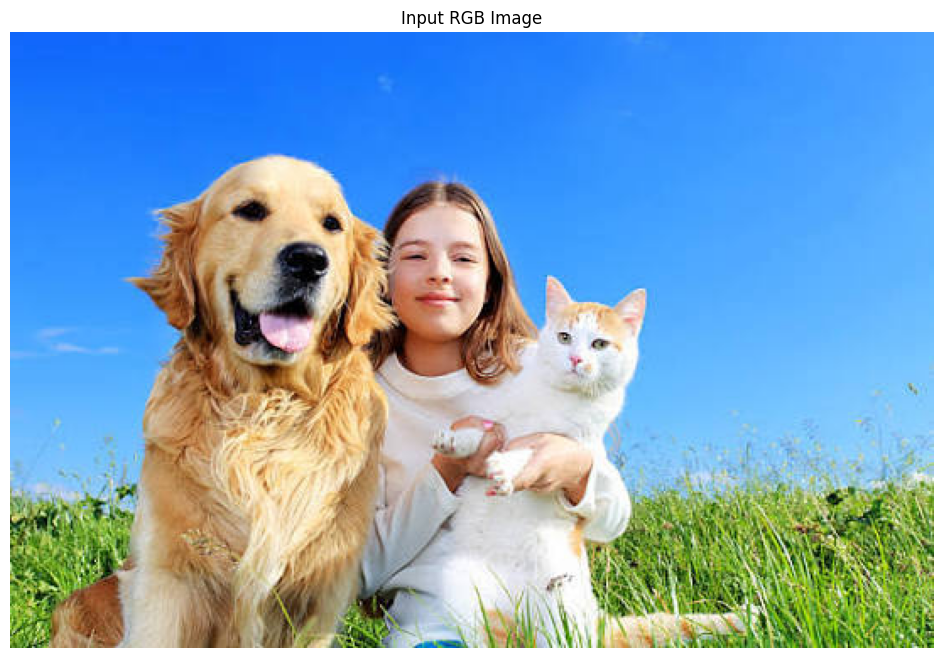

In [10]:
image = Image.open("/content/data/input/images4.jpeg").convert("RGB")
image_np = np.array(image)
H, W = image_np.shape[:2]

print("Image size:", image.size)
print("Image shape:", image_np.shape)

plt.figure(figsize=(12, 8))
plt.imshow(image_np)
plt.title("Input RGB Image")
plt.axis("off")
plt.show()

## 6. Semantic vocabulary

The vocabulary is kept compact so Grounding DINO does not spend unnecessary computation on dozens of labels. We also explicitly distinguish foreground objects, furniture, and background stuff.

In [11]:
TEXT_PROMPT = """
person . car . bicycle . motorcycle . bus . truck .
dog . cat . bird . chair . table . sofa .
tree . building . road . sky . grass . mountain .
water . sand . wall .
"""

SEMANTIC_GROUPS = {
    "foreground_object": {
        "person", "car", "bicycle", "motorcycle", "bus", "truck",
        "dog", "cat", "bird"
    },
    "furniture": {
        "chair", "table", "sofa"
    },
    "background_stuff": {
        "tree", "building", "road", "sky", "grass", "mountain",
        "water", "sand", "wall"
    }
}

def normalize_label(label):
    return str(label).strip().lower().rstrip(".")

def get_semantic_group(label):
    label = normalize_label(label)
    for group, labels in SEMANTIC_GROUPS.items():
        if label in labels:
            return group
    return "other"

## 7. Grounding DINO detection

In [12]:
def detect_objects(image, text_prompt, box_threshold=BOX_THRESHOLD, text_threshold=TEXT_THRESHOLD):
    inputs = processor(
        images=image,
        text=text_prompt,
        return_tensors="pt"
    )
    inputs = {k: v.to(DEVICE) if hasattr(v, "to") else v for k, v in inputs.items()}

    with torch.inference_mode():
        outputs = grounding_model(**inputs)

    results = processor.post_process_grounded_object_detection(
        outputs,
        inputs["input_ids"],
        threshold=box_threshold,
        text_threshold=text_threshold,
        target_sizes=[image.size[::-1]]
    )[0]

    return results

results = detect_objects(image, TEXT_PROMPT)

detections = []
for box, score, label in zip(results["boxes"], results["scores"], results["text_labels"]):
    detections.append({
        "label": normalize_label(label),
        "score": float(score),
        "box": box.detach().cpu().numpy().astype(np.float32)
    })

print("Raw detections:", len(detections))
for d in detections:
    print(f"{d['label']:15s} score={d['score']:.3f} box={np.round(d['box'], 1)}")

Raw detections: 8
dog             score=0.692 box=[ 21.7  70.9 230.4 365. ]
cat             score=0.367 box=[214.8 143.7 389.1 364.9]
sky             score=0.432 box=[3.000e-01 1.000e-01 5.464e+02 2.785e+02]
person          score=0.379 box=[205.7  86.6 373.8 363.2]
grass           score=0.369 box=[3.000e-01 2.147e+02 5.473e+02 3.615e+02]
person          score=0.413 box=[199.   87.2 444.  364. ]
grass           score=0.394 box=[1.000e-01 2.619e+02 5.470e+02 3.648e+02]
cat             score=0.364 box=[219.4 143.7 432.6 365.6]


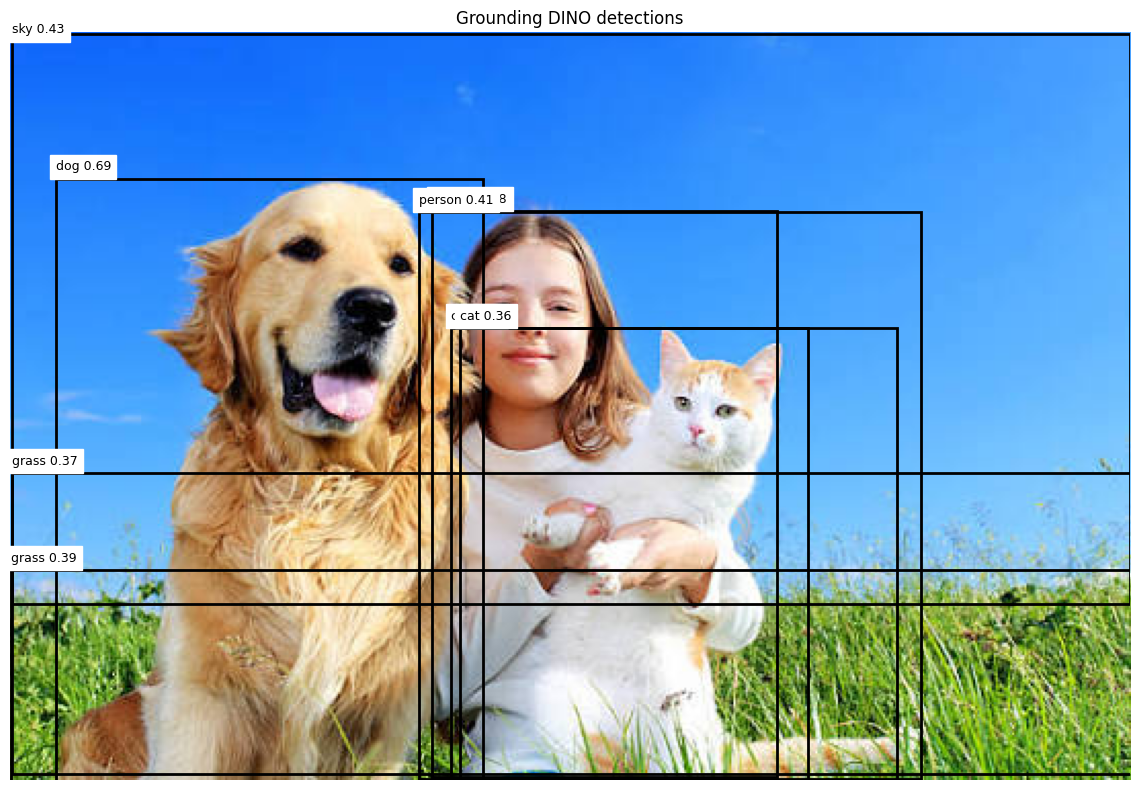

In [13]:
def show_detections(image_np, detections, title="Grounding DINO detections"):
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(image_np)
    for d in detections:
        x1, y1, x2, y2 = d["box"]
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, linewidth=2)
        ax.add_patch(rect)
        ax.text(x1, max(0, y1-4), f"{d['label']} {d['score']:.2f}",
                fontsize=9, backgroundcolor="white")
    ax.set_title(title)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

show_detections(image_np, detections)

## 8. Remove obvious duplicate detections


In [14]:
def box_area(box):
    x1, y1, x2, y2 = box
    return max(0.0, x2-x1) * max(0.0, y2-y1)

def calculate_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    inter = max(0.0, x2-x1) * max(0.0, y2-y1)
    union = box_area(box1) + box_area(box2) - inter
    return inter / union if union > 0 else 0.0

def containment_ratio(box_small, box_large):
    x1 = max(box_small[0], box_large[0])
    y1 = max(box_small[1], box_large[1])
    x2 = min(box_small[2], box_large[2])
    y2 = min(box_small[3], box_large[3])
    inter = max(0.0, x2-x1) * max(0.0, y2-y1)
    small = box_area(box_small)
    return inter / small if small > 0 else 0.0

def remove_duplicate_detections(detections, iou_threshold=DUPLICATE_IOU_THRESHOLD,
                                containment_threshold=DUPLICATE_CONTAINMENT_THRESHOLD):
    # High confidence first. Only same-label detections are treated as duplicates.
    ordered = sorted(detections, key=lambda d: d["score"], reverse=True)
    kept = []

    for d in ordered:
        is_duplicate = False
        for k in kept:
            if normalize_label(d["label"]) != normalize_label(k["label"]):
                continue
            iou = calculate_iou(d["box"], k["box"])
            containment = containment_ratio(d["box"], k["box"])
            if iou >= iou_threshold or containment >= containment_threshold:
                is_duplicate = True
                break
        if not is_duplicate:
            kept.append(d)
    return kept

raw_count = len(detections)
detections = remove_duplicate_detections(detections)
print(f"Detections: {raw_count} -> {len(detections)} after duplicate removal")

Detections: 8 -> 6 after duplicate removal


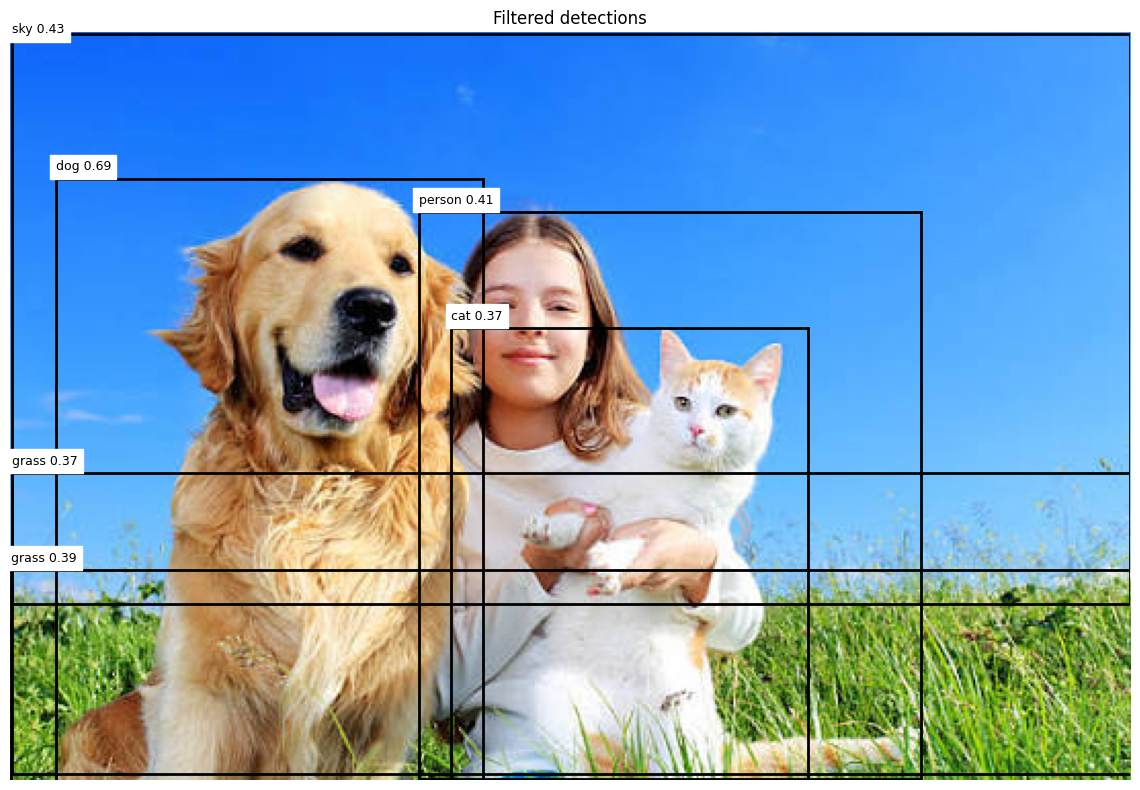

In [15]:
show_detections(image_np, detections, title="Filtered detections")

## 9. SAM 2 segmentation

In [16]:
def segment_box(predictor, box):
    masks, scores, _ = predictor.predict(
        box=np.asarray(box, dtype=np.float32),
        multimask_output=True
    )
    best_idx = int(np.argmax(scores))
    return masks[best_idx].astype(bool), float(scores[best_idx])

predictor.set_image(image_np)

layers = []
for idx, detection in enumerate(detections):
    mask, mask_score = segment_box(predictor, detection["box"])
    layers.append({
        "id": idx + 1,
        "label": detection["label"],
        "semantic_group": get_semantic_group(detection["label"]),
        "detection_score": detection["score"],
        "mask_score": mask_score,
        "box": detection["box"],
        "mask": mask
    })

print("Segmented layers:", len(layers))

Segmented layers: 6


## 10. Mask statistics and cleanup

In [17]:
def remove_small_components(mask, min_pixels=MIN_COMPONENT_PIXELS):
    mask_u8 = mask.astype(np.uint8)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask_u8, connectivity=8)
    cleaned = np.zeros_like(mask_u8)
    for i in range(1, num_labels):
        if stats[i, cv2.CC_STAT_AREA] >= min_pixels:
            cleaned[labels == i] = 1
    return cleaned.astype(bool)

def clean_mask(mask):
    mask_u8 = (mask.astype(np.uint8) * 255)
    kernel = np.ones((3, 3), np.uint8)
    mask_u8 = cv2.morphologyEx(mask_u8, cv2.MORPH_OPEN, kernel)
    mask_u8 = cv2.morphologyEx(mask_u8, cv2.MORPH_CLOSE, kernel)
    return remove_small_components(mask_u8 > 0)

valid_layers = []
for layer in layers:
    layer["mask"] = clean_mask(layer["mask"])
    layer["mask_area"] = int(layer["mask"].sum())
    layer["area_ratio"] = layer["mask_area"] / float(H * W)

    if (MIN_AREA_RATIO <= layer["area_ratio"] <= MAX_AREA_RATIO
            and layer["mask_score"] >= MIN_MASK_SCORE):
        valid_layers.append(layer)

layers = valid_layers
print("Valid layers after mask filtering:", len(layers))
for layer in layers:
    print(f"{layer['id']:02d} {layer['label']:15s} area={layer['area_ratio']:.3%} mask_score={layer['mask_score']:.3f}")

Valid layers after mask filtering: 6
01 dog             area=19.162% mask_score=0.976
02 sky             area=47.925% mask_score=0.971
03 person          area=17.390% mask_score=0.879
04 grass           area=10.799% mask_score=0.949
05 grass           area=11.295% mask_score=0.915
06 cat             area=9.875% mask_score=0.848


## 11. Monocular depth estimation

Depth map: (365, 547) range: 0.0 1.0


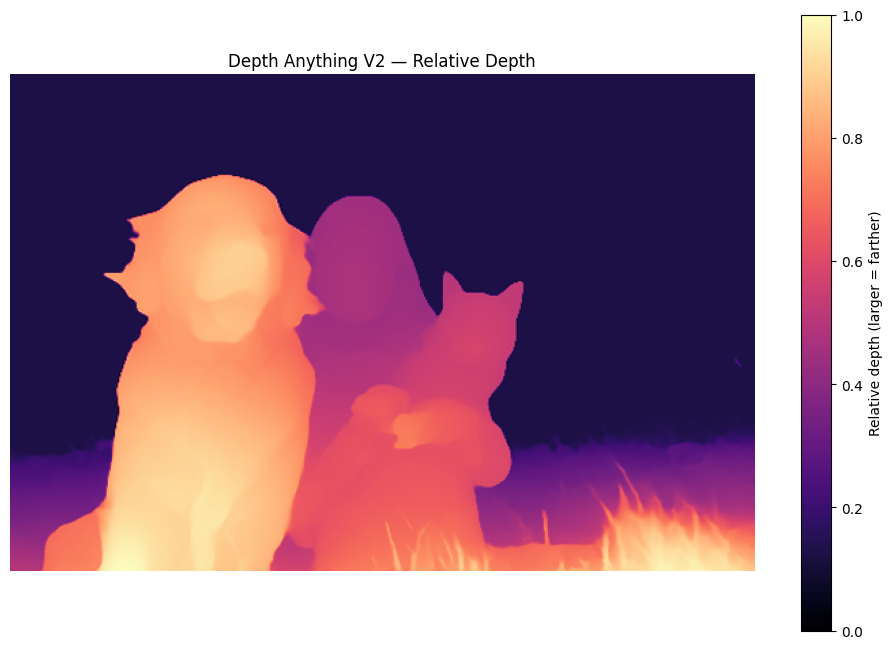

In [18]:
def estimate_depth(image_pil):
    inputs = depth_processor(images=image_pil, return_tensors="pt")
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

    with torch.inference_mode():
        outputs = depth_model(**inputs)

    processed = depth_processor.post_process_depth_estimation(
        outputs,
        target_sizes=[(image_pil.height, image_pil.width)]
    )

    predicted_depth = processed[0]["predicted_depth"]
    depth = predicted_depth.detach().float().cpu().numpy()

    # Normalize only for visualization/comparison. This is relative depth, not meters.
    dmin, dmax = float(depth.min()), float(depth.max())
    depth_norm = (depth - dmin) / (dmax - dmin + 1e-8)
    return depth_norm.astype(np.float32)

depth_map = estimate_depth(image)
print("Depth map:", depth_map.shape, "range:", float(depth_map.min()), float(depth_map.max()))

plt.figure(figsize=(12, 8))
plt.imshow(depth_map, cmap="magma")
plt.colorbar(label="Relative depth (larger = farther)")
plt.title("Depth Anything V2 — Relative Depth")
plt.axis("off")
plt.show()

In [19]:
depth_path = os.path.join(DEPTH_DIR, "depth_map.npy")
np.save(depth_path, depth_map)

depth_vis = (depth_map * 255).clip(0, 255).astype(np.uint8)
Image.fromarray(depth_vis).save(os.path.join(DEPTH_DIR, "depth_map.png"))
print("Saved depth outputs.")

Saved depth outputs.


## 12. Assign depth to each semantic layer

Depth is measured **inside the SAM mask**, not inside the bounding box. Median depth is used because it is more robust to outliers.

In [20]:
for layer in layers:
    values = depth_map[layer["mask"]]
    if values.size == 0:
        layer["depth"] = float("nan")
    else:
        layer["depth"] = float(np.median(values))

# Depth Anything V2 relative depth: larger values correspond to farther regions.
layers = [layer for layer in layers if np.isfinite(layer["depth"])]
layers.sort(key=lambda x: x["depth"])  # near -> far

for order, layer in enumerate(layers, start=1):
    layer["depth_order"] = order

print("Near -> far order:")
for layer in layers:
    print(f"{layer['depth_order']:02d}. {layer['label']:15s} depth={layer['depth']:.4f} group={layer['semantic_group']}")

Near -> far order:
01. sky             depth=0.1278 group=background_stuff
02. grass           depth=0.3943 group=background_stuff
03. grass           depth=0.4011 group=background_stuff
04. person          depth=0.5957 group=foreground_object
05. cat             depth=0.6210 group=foreground_object
06. dog             depth=0.8351 group=foreground_object


## 13. Make masks mutually exclusive using depth

SAM masks can overlap. For a layered representation, an overlapping pixel should belong to the nearest object. We therefore process layers near → far and remove already-claimed pixels from farther layers.

In [21]:
def make_exclusive_masks(layers, image_shape):
    used = np.zeros(image_shape[:2], dtype=bool)
    exclusive_layers = []

    for layer in layers:  # already near -> far
        exclusive_mask = layer["mask"] & (~used)
        layer = dict(layer)
        layer["mask"] = exclusive_mask
        layer["mask_area"] = int(exclusive_mask.sum())
        layer["area_ratio"] = layer["mask_area"] / float(H * W)
        used |= exclusive_mask
        exclusive_layers.append(layer)

    return exclusive_layers, used

layers, foreground_union = make_exclusive_masks(layers, image_np.shape)

# Remove objects that become empty after overlap resolution.
layers = [l for l in layers if l["mask_area"] > 0]
for order, layer in enumerate(layers, start=1):
    layer["depth_order"] = order

print("Non-overlapping foreground layers:", len(layers))

Non-overlapping foreground layers: 4


## 14. Add the background layer

In [22]:
background_mask = ~foreground_union
background_layer = {
    "id": len(layers) + 1,
    "label": "background",
    "semantic_group": "background_stuff",
    "detection_score": 1.0,
    "mask_score": 1.0,
    "box": np.array([0, 0, W, H], dtype=np.float32),
    "mask": background_mask,
    "mask_area": int(background_mask.sum()),
    "area_ratio": float(background_mask.mean()),
    "depth": 1.0,
    "depth_order": len(layers) + 1
}

# Store the background separately so foreground depth order remains explicit.
all_layers = layers + [background_layer]
print("Total output layers including background:", len(all_layers))

Total output layers including background: 5


## 15. Create clean RGBA layers

In [23]:
def create_rgba_layer(image_np, mask):
    rgba = np.zeros((*image_np.shape[:2], 4), dtype=np.uint8)
    rgba[:, :, :3] = image_np * mask[:, :, None]
    rgba[:, :, 3] = mask.astype(np.uint8) * 255
    return rgba

for layer in all_layers:
    layer["rgba"] = create_rgba_layer(image_np, layer["mask"])

print("RGBA layers created.")

RGBA layers created.


## 16. Save RGBA layers

In [24]:
def safe_filename(text):
    return "".join(ch if ch.isalnum() or ch in "-_" else "_" for ch in str(text))

for layer in all_layers:
    filename = f"layer_{layer['depth_order']:02d}_{safe_filename(layer['label'])}.png"
    path = os.path.join(LAYER_DIR, filename)
    Image.fromarray(layer["rgba"], mode="RGBA").save(path)
    layer["path"] = path
    print("Saved:", path)

Saved: /content/results/layers/layer_01_sky.png
Saved: /content/results/layers/layer_02_grass.png
Saved: /content/results/layers/layer_03_person.png
Saved: /content/results/layers/layer_04_dog.png
Saved: /content/results/layers/layer_05_background.png


/tmp/ipykernel_3034/2484127639.py:7: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(layer["rgba"], mode="RGBA").save(path)


## 17. Layer visualization

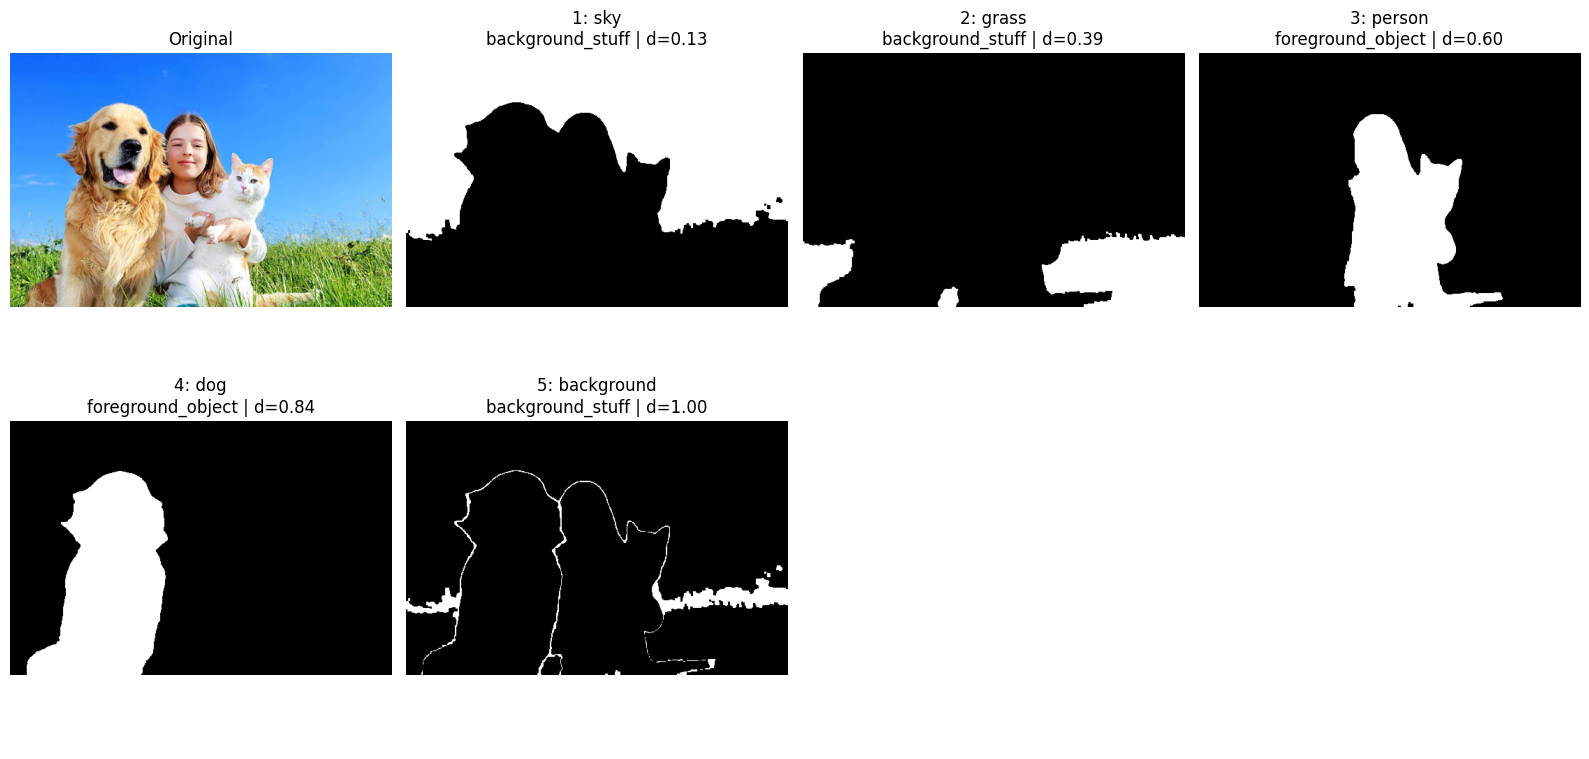

In [25]:
def visualize_layers(image_np, layers, max_cols=4):
    n = len(layers) + 1
    cols = min(max_cols, n)
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
    axes = np.array(axes).reshape(-1)

    axes[0].imshow(image_np)
    axes[0].set_title("Original")
    axes[0].axis("off")

    for i, layer in enumerate(layers, start=1):
        axes[i].imshow(layer["mask"], cmap="gray")
        axes[i].set_title(
            f"{layer['depth_order']}: {layer['label']}\n"
            f"{layer['semantic_group']} | d={layer['depth']:.2f}"
        )
        axes[i].axis("off")

    for j in range(n, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.savefig(os.path.join(VIS_DIR, "layer_masks.png"), dpi=150, bbox_inches="tight")
    plt.show()

visualize_layers(image_np, all_layers)

## 18. Depth-aware scene map

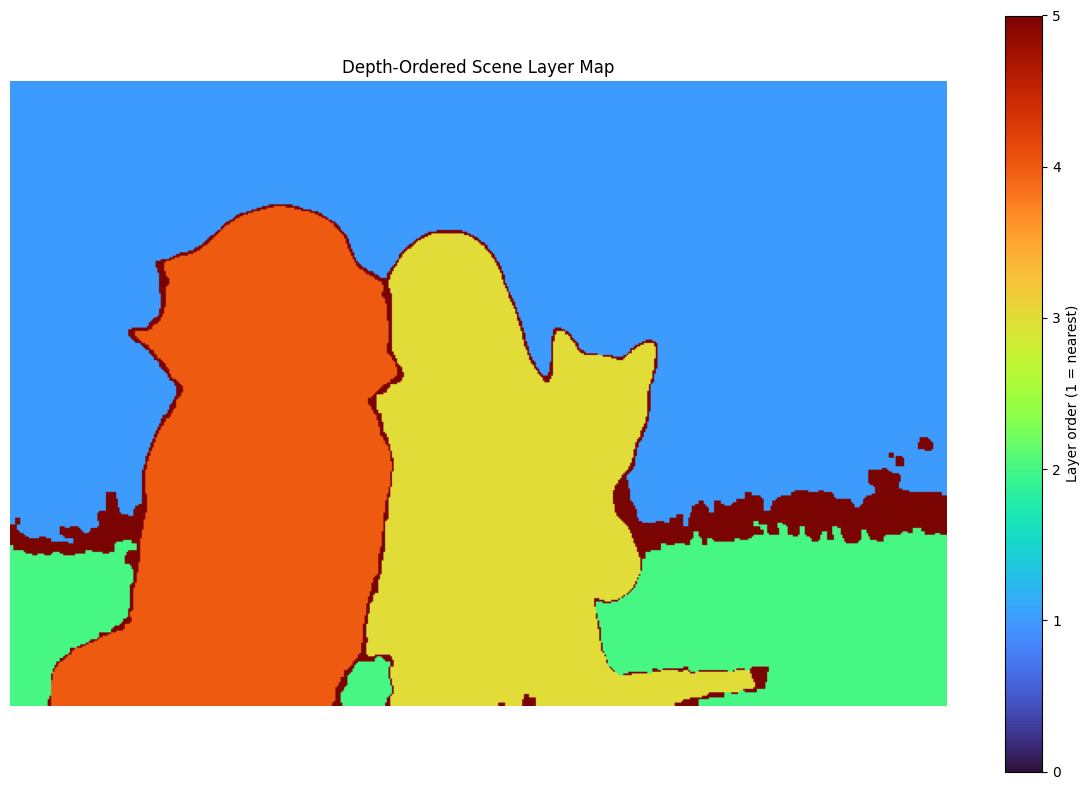

In [26]:
def create_scene_map(layers, image_shape):
    scene_map = np.zeros(image_shape[:2], dtype=np.int32)
    for layer in layers:
        scene_map[layer["mask"]] = layer["depth_order"]
    return scene_map

scene_map = create_scene_map(all_layers, image_np.shape)

plt.figure(figsize=(12, 8))
plt.imshow(scene_map, cmap="turbo", vmin=0, vmax=max(1, len(all_layers)))
plt.colorbar(label="Layer order (1 = nearest)")
plt.title("Depth-Ordered Scene Layer Map")
plt.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, "scene_layer_map.png"), dpi=150, bbox_inches="tight")
plt.show()

## 19. Recompose the scene from the RGBA stack

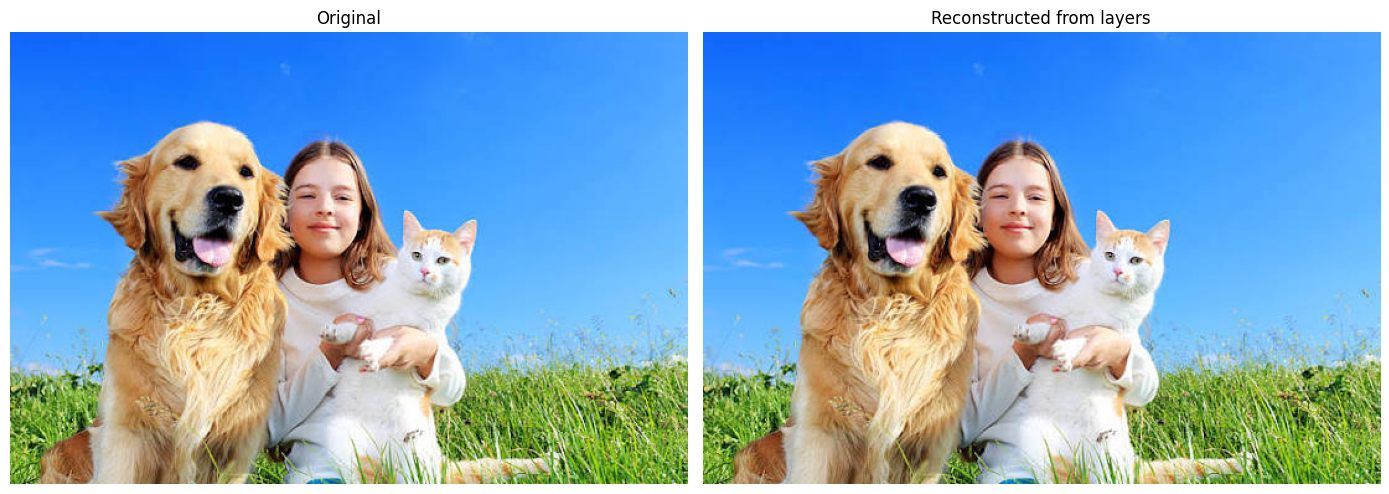

In [27]:
def alpha_composite_rgba(base_rgb, rgba):
    alpha = rgba[:, :, 3:4].astype(np.float32) / 255.0
    fg = rgba[:, :, :3].astype(np.float32)
    base = base_rgb.astype(np.float32)
    out = fg * alpha + base * (1.0 - alpha)
    return np.clip(out, 0, 255).astype(np.uint8)

def recompose_layers(layers, image_shape):
    # Background first, then far -> near foreground.
    background = next(l for l in layers if l["label"] == "background")
    base = background["rgba"][:, :, :3].copy()

    foreground = [l for l in layers if l["label"] != "background"]
    foreground = sorted(foreground, key=lambda x: x["depth"], reverse=True)

    for layer in foreground:
        base = alpha_composite_rgba(base, layer["rgba"])
    return base

reconstructed = recompose_layers(all_layers, image_np.shape)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(image_np)
axes[0].set_title("Original")
axes[0].axis("off")
axes[1].imshow(reconstructed)
axes[1].set_title("Reconstructed from layers")
axes[1].axis("off")
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, "reconstruction.png"), dpi=150, bbox_inches="tight")
plt.show()

## 20. Reconstruction quality

In [28]:
def reconstruction_metrics(original, reconstructed):
    a = original.astype(np.float32) / 255.0
    b = reconstructed.astype(np.float32) / 255.0
    mae = float(np.mean(np.abs(a-b)))
    mse = float(np.mean((a-b)**2))
    psnr = float("inf") if mse == 0 else float(10 * np.log10(1.0 / mse))
    return mae, mse, psnr

mae, mse, psnr = reconstruction_metrics(image_np, reconstructed)
print(f"Reconstruction MAE : {mae:.6f}")
print(f"Reconstruction MSE : {mse:.6f}")
print(f"Reconstruction PSNR: {psnr:.2f} dB")

Image.fromarray(reconstructed).save(os.path.join(VIS_DIR, "reconstructed.png"))

Reconstruction MAE : 0.000000
Reconstruction MSE : 0.000000
Reconstruction PSNR: inf dB


## 21. Optional: approximate albedo + shading per layer

This is deliberately a lightweight **stretch component**, not a physically accurate intrinsic-image model. It estimates a smooth illumination/shading field from luminance and divides the RGB image by that field to obtain an approximate albedo.

In [29]:
def approximate_intrinsic(image_np, mask, blur_sigma=15.0):
    rgb = image_np.astype(np.float32) / 255.0
    luminance = (0.2126*rgb[:,:,0] + 0.7152*rgb[:,:,1] + 0.0722*rgb[:,:,2])
    illumination = cv2.GaussianBlur(luminance, (0, 0), blur_sigma)
    values = illumination[mask]
    scale = float(np.median(values)) if values.size else 0.5
    shading = illumination / (scale + 1e-6)
    shading = np.clip(shading, 0.25, 2.0)

    albedo = np.clip(rgb / shading[:,:,None], 0, 1)
    shading_vis = np.clip(shading / 2.0, 0, 1)

    albedo_rgba = np.zeros((*image_np.shape[:2], 4), dtype=np.uint8)
    albedo_rgba[:,:,:3] = (albedo * 255).astype(np.uint8) * mask[:,:,None]
    albedo_rgba[:,:,3] = mask.astype(np.uint8) * 255

    shading_rgb = np.repeat((shading_vis*255).astype(np.uint8)[:,:,None], 3, axis=2)
    shading_rgba = np.zeros((*image_np.shape[:2], 4), dtype=np.uint8)
    shading_rgba[:,:,:3] = shading_rgb * mask[:,:,None]
    shading_rgba[:,:,3] = mask.astype(np.uint8) * 255

    return albedo_rgba, shading_rgba

# Run for all layers. This is optional and can be skipped if runtime is tight.
for layer in all_layers:
    albedo_rgba, shading_rgba = approximate_intrinsic(image_np, layer["mask"])
    layer["albedo_rgba"] = albedo_rgba
    layer["shading_rgba"] = shading_rgba

    stem = f"layer_{layer['depth_order']:02d}_{safe_filename(layer['label'])}"
    Image.fromarray(albedo_rgba, mode="RGBA").save(os.path.join(ALBEDO_DIR, stem + "_albedo.png"))
    Image.fromarray(shading_rgba, mode="RGBA").save(os.path.join(ALBEDO_DIR, stem + "_shading.png"))

print("Approximate albedo/shading outputs saved.")

/tmp/ipykernel_3034/3204608561.py:31: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(albedo_rgba, mode="RGBA").save(os.path.join(ALBEDO_DIR, stem + "_albedo.png"))
/tmp/ipykernel_3034/3204608561.py:32: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(shading_rgba, mode="RGBA").save(os.path.join(ALBEDO_DIR, stem + "_shading.png"))


Approximate albedo/shading outputs saved.


## 22. Visual quality report


In [30]:
def quality_report(layers):
    foreground = [l for l in layers if l["label"] != "background"]
    return {
        "total_layers": len(layers),
        "foreground_layers": len(foreground),
        "background_present": any(l["label"] == "background" for l in layers),
        "semantic_groups": sorted(set(l["semantic_group"] for l in layers)),
        "mean_detection_score": float(np.mean([l["detection_score"] for l in foreground])) if foreground else 0.0,
        "mean_mask_score": float(np.mean([l["mask_score"] for l in foreground])) if foreground else 0.0,
        "reconstruction_mae": mae,
        "reconstruction_mse": mse,
        "reconstruction_psnr_db": psnr
    }

report = quality_report(all_layers)
for k, v in report.items():
    print(f"{k}: {v}")

total_layers: 5
foreground_layers: 4
background_present: True
semantic_groups: ['background_stuff', 'foreground_object']
mean_detection_score: 0.4764830470085144
mean_mask_score: 0.9353377521038055
reconstruction_mae: 0.0
reconstruction_mse: 0.0
reconstruction_psnr_db: inf


## 23. Save metadata

The JSON records semantic grouping, depth, ordering, mask statistics, and output paths so the representation can be consumed by downstream applications.

In [31]:
metadata = {
    "project": "Layered Representations from a Single Image",
    "image": IMAGE_PATH,
    "image_height": int(H),
    "image_width": int(W),
    "models": {
        "detection": GROUNDING_MODEL_ID,
        "segmentation": SAM2_MODEL_ID,
        "depth": DEPTH_MODEL_ID
    },
    "settings": {
        "box_threshold": BOX_THRESHOLD,
        "text_threshold": TEXT_THRESHOLD,
        "duplicate_iou_threshold": DUPLICATE_IOU_THRESHOLD,
        "min_area_ratio": MIN_AREA_RATIO,
        "max_area_ratio": MAX_AREA_RATIO
    },
    "num_layers": len(all_layers),
    "reconstruction": {
        "mae": mae,
        "mse": mse,
        "psnr_db": psnr
    },
    "layers": []
}

for layer in all_layers:
    metadata["layers"].append({
        "id": int(layer["id"]),
        "depth_order": int(layer["depth_order"]),
        "label": layer["label"],
        "semantic_group": layer["semantic_group"],
        "detection_score": float(layer["detection_score"]),
        "mask_score": float(layer["mask_score"]),
        "depth": float(layer["depth"]),
        "mask_area": int(layer["mask_area"]),
        "area_ratio": float(layer["area_ratio"]),
        "box": [float(x) for x in layer["box"]],
        "rgba_path": layer["path"]
    })

metadata_path = os.path.join(RESULTS_DIR, "metadata.json")
with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=4)

print("Saved:", metadata_path)

Saved: /content/results/metadata.json


## 24. Final layer table

In [32]:
print("\nFINAL LAYER STACK — NEAR → FAR")
print("=" * 80)
for layer in all_layers:
    print(
        f"{layer['depth_order']:02d} | "
        f"{layer['label']:15s} | "
        f"{layer['semantic_group']:20s} | "
        f"depth={layer['depth']:.3f} | "
        f"area={layer['area_ratio']:.2%}"
    )

print("\nResults directory:", RESULTS_DIR)
print("Metadata:", metadata_path)


FINAL LAYER STACK — NEAR → FAR
01 | sky             | background_stuff     | depth=0.128 | area=47.93%
02 | grass           | background_stuff     | depth=0.394 | area=11.29%
03 | person          | foreground_object    | depth=0.596 | area=17.39%
04 | dog             | foreground_object    | depth=0.835 | area=19.16%
05 | background      | background_stuff     | depth=1.000 | area=4.23%

Results directory: /content/results
Metadata: /content/results/metadata.json


## 25. Optional 2.5D parallax demo

This does not require another model. It shifts each transparent layer by an amount inversely related to depth, demonstrating why the depth-ordered representation is useful for animation.

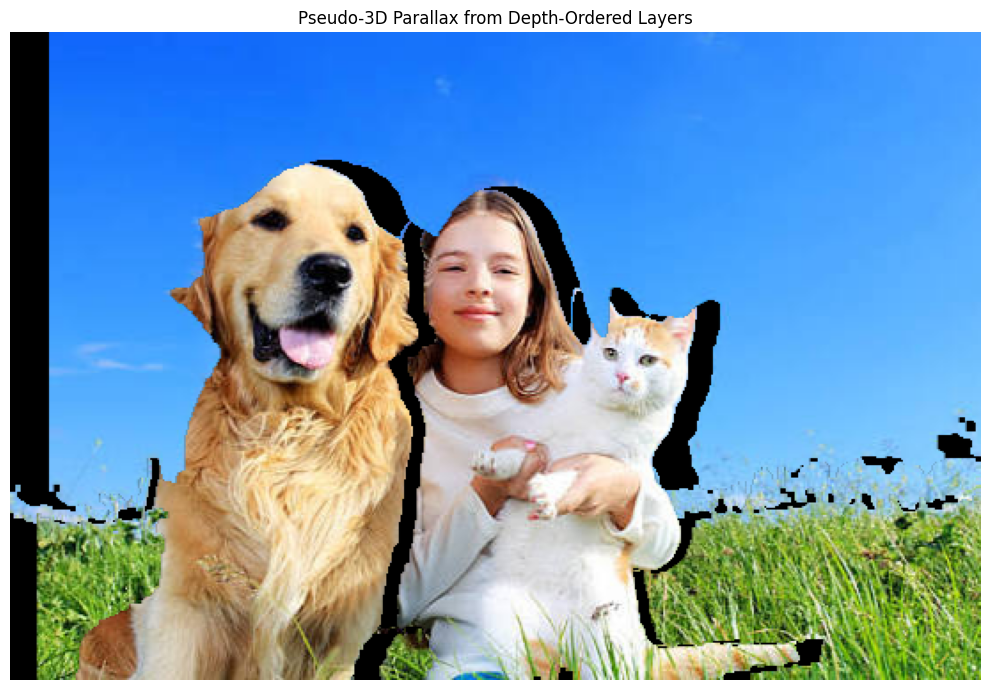

In [33]:
def shift_rgba(rgba, dx, dy=0):
    h, w = rgba.shape[:2]
    M = np.float32([[1, 0, dx], [0, 1, dy]])
    return cv2.warpAffine(
        rgba, M, (w, h),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=(0,0,0,0)
    )

def render_parallax(layers, camera_shift=25):
    canvas = np.zeros((*image_np.shape[:2], 3), dtype=np.uint8)
    background = next(l for l in layers if l["label"] == "background")
    canvas = background["rgba"][:,:,:3].copy()

    foreground = sorted(
        [l for l in layers if l["label"] != "background"],
        key=lambda x: x["depth"],
        reverse=True
    )

    for layer in foreground:
        # Near layers move more than far layers.
        amount = camera_shift * (1.0 - layer["depth"])
        moved = shift_rgba(layer["rgba"], amount)
        canvas = alpha_composite_rgba(canvas, moved)
    return canvas

parallax = render_parallax(all_layers, camera_shift=25)
plt.figure(figsize=(12, 7))
plt.imshow(parallax)
plt.title("Pseudo-3D Parallax from Depth-Ordered Layers")
plt.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, "parallax_demo.png"), dpi=150, bbox_inches="tight")
plt.show()